# Group 1 — AI Content Detection: Retrain with New Real-World Data

**Problem:** Model predicts 100% AI-generated for real human photos.  
**Fix:** Add diverse real-world photos (Flickr30k) to the REAL class + complete Phase 2 fine-tuning.  
**Runtime:** ~60–90 min on Colab T4 GPU

**Steps:**
1. Setup & mount Drive
2. Download Flickr30k real photos (Kaggle)
3. Clean & deduplicate images
4. Create balanced train/val/test splits
5. Load existing model weights
6. Phase 2 fine-tuning (unfreeze all layers)
7. Evaluate (confusion matrix, accuracy, F1, ROC)
8. Save new weights

## Step 1 — Setup

In [3]:
from google.colab import files, drive
import os

# Mount Google Drive (weights will be saved here)
drive.mount('/content/drive')

# Upload kaggle.json via file picker
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Configure Kaggle API
!pip install kaggle --quiet
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(uploaded[filename])
!chmod 600 ~/.kaggle/kaggle.json

print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving kaggle.json to kaggle (1).json
Setup complete.


## Step 2 — Data Collection: Download Real-World Photos

In [4]:
import os

# Create data directories
os.makedirs('/content/data/raw/new_real', exist_ok=True)
os.makedirs('/content/data/raw/fake_faces', exist_ok=True)
os.makedirs('/content/data/processed', exist_ok=True)

# Download Flickr30k — diverse real-world photos (people, scenes, animals, objects)
# This gives ~31,000 real photos taken by real cameras
print('Downloading Flickr30k images...')
!kaggle datasets download -d hsankesara/flickr-image-dataset -p /content/data/raw/ --quiet
!unzip -q /content/data/raw/flickr-image-dataset.zip -d /content/data/raw/new_real/

# Download real-and-fake faces dataset — real faces (from Flickr/real cameras)
print('Downloading Real & Fake Faces dataset...')
!kaggle datasets download -d ciplab/real-and-fake-face-detection -p /content/data/raw/ --quiet
!unzip -q /content/data/raw/real-and-fake-face-detection.zip -d /content/data/raw/
print('Download complete.')

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
Download complete.


In [5]:
import glob

# Real photos — Flickr30k (diverse scenes, people, animals)
flickr_paths = glob.glob('/content/data/raw/new_real/flickr30k_images/flickr30k_images/*.jpg')

# Real face photos from ciplab dataset
real_face_paths = (
    glob.glob('/content/data/raw/real_and_fake_face/training_real/*.jpg') +
    glob.glob('/content/data/raw/real_and_fake_face_detection/real_and_fake_face/training_real/*.jpg')
)

# AI-generated face photos from ciplab dataset
fake_face_paths = (
    glob.glob('/content/data/raw/real_and_fake_face/training_fake/*.jpg') +
    glob.glob('/content/data/raw/real_and_fake_face_detection/real_and_fake_face/training_fake/*.jpg')
)

print(f'Flickr real photos:  {len(flickr_paths):,}')
print(f'Real face photos:    {len(real_face_paths):,}')
print(f'Fake face photos:    {len(fake_face_paths):,}')

Flickr real photos:  31,783
Real face photos:    2,162
Fake face photos:    1,920


## Step 3 — Data Cleaning: Remove Corrupted & Duplicate Images

In [6]:
import hashlib
from PIL import Image
from tqdm import tqdm

def clean_images(paths, label_name, max_samples=10000):
    """Remove corrupted, too-small, and duplicate images."""
    seen_hashes = set()
    clean = []

    for path in tqdm(paths, desc=f'Cleaning {label_name}'):
        try:
            img = Image.open(path).convert('RGB')
            w, h = img.size

            # Skip images that are too small
            if w < 100 or h < 100:
                continue

            # Skip duplicates using image hash
            img_hash = hashlib.md5(img.tobytes()).hexdigest()
            if img_hash in seen_hashes:
                continue
            seen_hashes.add(img_hash)

            clean.append(path)

            if len(clean) >= max_samples:
                break

        except Exception:
            continue  # Skip corrupted files

    print(f'{label_name}: {len(clean):,} clean images (from {len(paths):,} total)')
    return clean


# Clean all image sets
# REAL: combine Flickr + real faces, cap at 10,000 for balance
all_real_paths = flickr_paths + real_face_paths
clean_real = clean_images(all_real_paths, 'REAL', max_samples=10000)

# FAKE: use AI-generated faces, cap at 10,000 for balance
clean_fake = clean_images(fake_face_paths, 'AI_GENERATED', max_samples=10000)

print(f'\nFinal dataset: {len(clean_real):,} REAL + {len(clean_fake):,} AI_GENERATED')

Cleaning REAL:  29%|██▉       | 9999/33945 [01:09<02:46, 143.69it/s]


REAL: 10,000 clean images (from 33,945 total)


Cleaning AI_GENERATED: 100%|██████████| 1920/1920 [00:18<00:00, 106.54it/s]

AI_GENERATED: 960 clean images (from 1,920 total)

Final dataset: 10,000 REAL + 960 AI_GENERATED


## Step 4 — Create Train / Val / Test Splits

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Build full dataframe: filepath + label (0=REAL, 1=AI_GENERATED)
real_df = pd.DataFrame({'filepath': clean_real, 'label': 0})
fake_df = pd.DataFrame({'filepath': clean_fake, 'label': 1})
full_df = pd.concat([real_df, fake_df], ignore_index=True).sample(frac=1, random_state=42)

# Split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(full_df, test_size=0.30, stratify=full_df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df,  test_size=0.50, stratify=temp_df['label'],  random_state=42)

# Save CSV manifests
train_df.to_csv('/content/data/processed/train.csv', index=False)
val_df.to_csv('/content/data/processed/val.csv',     index=False)
test_df.to_csv('/content/data/processed/test.csv',   index=False)

print(f'Train: {len(train_df):,} images  ({train_df.label.value_counts()[0]:,} REAL, {train_df.label.value_counts()[1]:,} AI)')
print(f'Val:   {len(val_df):,}  images  ({val_df.label.value_counts()[0]:,} REAL, {val_df.label.value_counts()[1]:,} AI)')
print(f'Test:  {len(test_df):,}  images  ({test_df.label.value_counts()[0]:,} REAL, {test_df.label.value_counts()[1]:,} AI)')

Train: 7,672 images  (7,000 REAL, 672 AI)
Val:   1,644  images  (1,500 REAL, 144 AI)
Test:  1,644  images  (1,500 REAL, 144 AI)


## Step 5 — Dataset Class & Transforms

In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image

# Image transforms (same as original training pipeline)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class ImageDataset(Dataset):
    """Loads images from a CSV manifest (filepath, label)."""
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label


# Create datasets
train_dataset = ImageDataset('/content/data/processed/train.csv', transform=train_transform)
val_dataset   = ImageDataset('/content/data/processed/val.csv',   transform=val_transform)
test_dataset  = ImageDataset('/content/data/processed/test.csv',  transform=val_transform)

# WeightedRandomSampler — balances REAL vs AI_GENERATED in each batch
train_labels = train_df['label'].values
class_counts = [sum(train_labels == 0), sum(train_labels == 1)]
class_weights = [1.0 / c for c in class_counts]
sample_weights = [class_weights[int(label)] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,   num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')
print(f'Class balance: {class_counts[0]:,} REAL vs {class_counts[1]:,} AI_GENERATED')

Train batches: 240
Val batches:   52
Test batches:  52
Class balance: 7,000 REAL vs 672 AI_GENERATED


## Step 6 — Load Existing Model Weights

In [9]:
import torch
import torch.nn as nn
import torchvision.models as models

# Path to existing weights on Google Drive
WEIGHTS_PATH = '/content/drive/MyDrive/efficientnet_b0_finetuned.pth'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


def build_model():
    """Build EfficientNet-B0 with custom 2-class head."""
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, 2),
    )
    return model


# Load model with existing weights
model = build_model()
state_dict = torch.load(WEIGHTS_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)

print('Existing weights loaded successfully.')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: cuda
Existing weights loaded successfully.
Total parameters: 4,010,110


## Step 7 — Phase 2 Fine-Tuning (Unfreeze All Layers)

In [10]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Unfreeze ALL layers for Phase 2
for param in model.parameters():
    param.requires_grad = True

EPOCHS   = 8
LR       = 2e-5
PATIENCE = 3

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Weighted loss — penalises missing AI images more (fixes class imbalance)
class_weights_tensor = torch.tensor(
    [class_counts[1] / sum(class_counts), class_counts[0] / sum(class_counts)],
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Save directly to Drive so weights survive session restarts
best_weights_path = '/content/drive/MyDrive/efficientnet_b0_v2.pth'
best_val_acc = 0.0
patience_counter = 0
history = []


def evaluate(loader):
    """Compute accuracy on a DataLoader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


print(f'Starting Phase 2 fine-tuning for up to {EPOCHS} epochs...\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f'  Epoch {epoch} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {running_loss/(batch_idx+1):.4f}')

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    val_acc    = evaluate(val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_acc': val_acc})
    print(f'Epoch {epoch}/{EPOCHS} — Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_weights_path)
        print(f'  Best model saved to Drive (val_acc={best_val_acc:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print('Early stopping triggered.')
            break

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.4f}')

Starting Phase 2 fine-tuning for up to 8 epochs...

  Epoch 1 | Batch 50/240 | Loss: 0.6484
  Epoch 1 | Batch 100/240 | Loss: 0.3659
  Epoch 1 | Batch 150/240 | Loss: 0.2601
  Epoch 1 | Batch 200/240 | Loss: 0.2037
Epoch 1/8 — Loss: 0.1742 | Val Acc: 0.9665
  Best model saved to Drive (val_acc=0.9665)
  Epoch 2 | Batch 50/240 | Loss: 0.0214
  Epoch 2 | Batch 100/240 | Loss: 0.0215
  Epoch 2 | Batch 150/240 | Loss: 0.0198
  Epoch 2 | Batch 200/240 | Loss: 0.0187
Epoch 2/8 — Loss: 0.0181 | Val Acc: 0.9769
  Best model saved to Drive (val_acc=0.9769)
  Epoch 3 | Batch 50/240 | Loss: 0.0178
  Epoch 3 | Batch 100/240 | Loss: 0.0140
  Epoch 3 | Batch 150/240 | Loss: 0.0136
  Epoch 3 | Batch 200/240 | Loss: 0.0133
Epoch 3/8 — Loss: 0.0129 | Val Acc: 0.9878
  Best model saved to Drive (val_acc=0.9878)
  Epoch 4 | Batch 50/240 | Loss: 0.0107
  Epoch 4 | Batch 100/240 | Loss: 0.0096
  Epoch 4 | Batch 150/240 | Loss: 0.0109
  Epoch 4 | Batch 200/240 | Loss: 0.0105
Epoch 4/8 — Loss: 0.0099 | Val A

## Step 8 — Evaluation (Confusion Matrix, Accuracy, F1, ROC)

=== Classification Report ===
              precision    recall  f1-score   support

        REAL       1.00      0.99      1.00      1500
AI_GENERATED       0.94      0.99      0.97       144

    accuracy                           0.99      1644
   macro avg       0.97      0.99      0.98      1644
weighted avg       0.99      0.99      0.99      1644



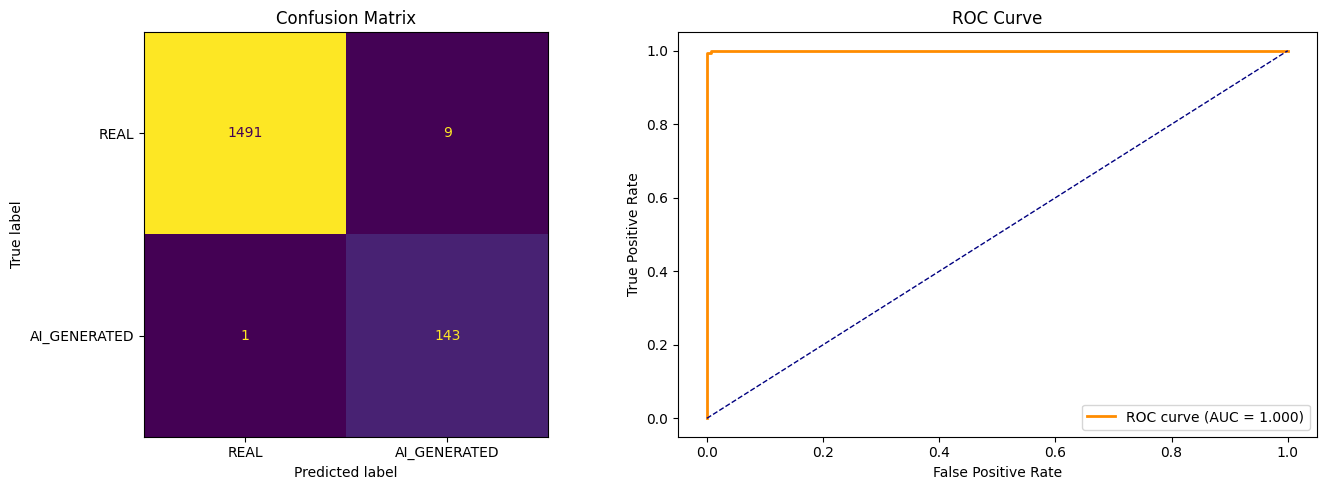


AUC: 0.9999


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

# Load best weights
model.load_state_dict(torch.load(best_weights_path, map_location=device, weights_only=True))
model.eval()

# Collect predictions on test set
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # AI probability

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Classification report
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['REAL', 'AI_GENERATED']))

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL', 'AI_GENERATED'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# Plot ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('/content/data/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nAUC: {roc_auc:.4f}')

In [14]:
# Manual test — upload your own real photos to verify REAL prediction
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from google.colab import files

device = 'cuda' if torch.cuda.is_available() else 'cpu'

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('Upload photos to test:')
uploaded = files.upload()

for filename, content in uploaded.items():
    tmp_path = '/tmp/test_image.png'
    with open(tmp_path, 'wb') as f:
        f.write(content)

    img = Image.open(tmp_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs  = F.softmax(model(tensor), dim=1)
        ai_prob = float(probs[0][1])
        label = 'AI_GENERATED' if ai_prob >= 0.50 else 'REAL'
        confidence = ai_prob if label == 'AI_GENERATED' else float(probs[0][0])

    print(f'{filename}: {label} ({confidence*100:.1f}% confidence)')

Upload photos to test:


Saving Gemini_Generated_Image_ufxtviufxtviufxt.png to Gemini_Generated_Image_ufxtviufxtviufxt.png
Gemini_Generated_Image_ufxtviufxtviufxt.png: REAL (98.7% confidence)


## Step 9 — Save New Weights to Drive

In [15]:
# Load best weights and save final model to Drive
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
final_save_path = '/content/drive/MyDrive/efficientnet_b0_v2.pth'

# If model is still in memory from training, just re-save
# Otherwise reload from the best checkpoint already on Drive
try:
    torch.save(model.state_dict(), final_save_path)
    print(f'Model v2 saved to: {final_save_path}')
except NameError:
    print(f'Model already saved to Drive at: {final_save_path}')
    print('(Training saved it directly — no action needed)')

print()
print('Next steps:')
print('1. Download efficientnet_b0_v2.pth from Google Drive')
print('2. Replace: backend/model/weights/efficientnet_b0_finetuned.pth')
print('3. inference.py threshold is already set to 0.50')
print('4. Restart the FastAPI backend')

Model v2 saved to: /content/drive/MyDrive/efficientnet_b0_v2.pth

Next steps:
1. Download efficientnet_b0_v2.pth from Google Drive
2. Replace: backend/model/weights/efficientnet_b0_finetuned.pth
3. inference.py threshold is already set to 0.50
4. Restart the FastAPI backend


## Training History Summary

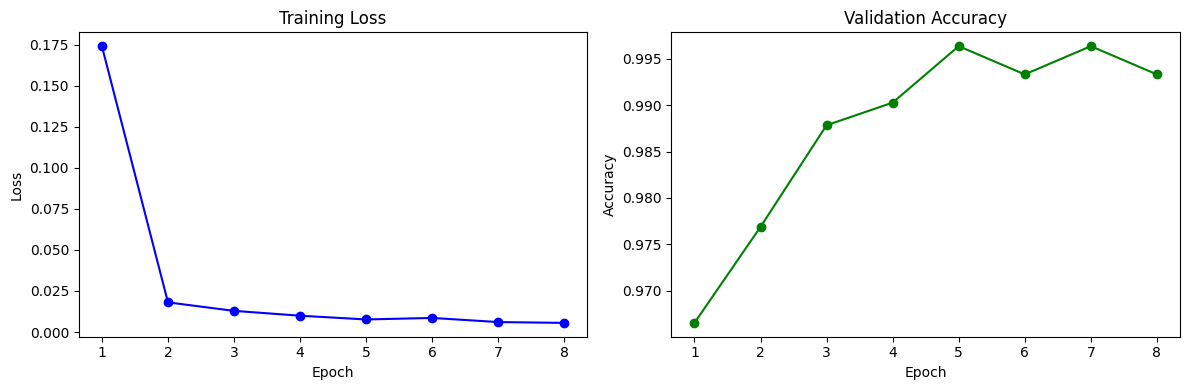

Training History:
  Epoch 1: loss=0.1742, val_acc=0.9665
  Epoch 2: loss=0.0181, val_acc=0.9769
  Epoch 3: loss=0.0129, val_acc=0.9878
  Epoch 4: loss=0.0099, val_acc=0.9903
  Epoch 5: loss=0.0077, val_acc=0.9964
  Epoch 6: loss=0.0086, val_acc=0.9933
  Epoch 7: loss=0.0061, val_acc=0.9964
  Epoch 8: loss=0.0056, val_acc=0.9933


In [16]:
# Plot training loss and val accuracy over epochs
epochs_list = [h['epoch'] for h in history]
losses      = [h['train_loss'] for h in history]
val_accs    = [h['val_acc'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_list, losses, 'b-o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(epochs_list, val_accs, 'g-o')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('/content/data/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print('Training History:')
for h in history:
    print(f"  Epoch {h['epoch']}: loss={h['train_loss']:.4f}, val_acc={h['val_acc']:.4f}")